# Descriptive Implementation of Linear Discrement Analysis

The detailed mathematical formulation of the algotihm is demonstrared below 

Input

$$
D=\{(x_1,y_1),(x_2,y_2),\ldots,(x_n,y_n)\}
$$

where

$$
x_i\in\mathbb{R}^{N}, \qquad y_i\in\{1,2,\ldots,C\}
$$

---

Step 1: Compute Class Mean Vectors

For each class,

$$
\mu_i=\frac{1}{N_i}\sum_{x\in D_i}x
$$

Overall mean,

$$
\mu=\frac{1}{N}\sum_{i=1}^{N}x_i
$$

---

Step 2: Compute Within-Class Scatter Matrix

$$
S_W=\sum_{i=1}^{C}\sum_{x\in D_i}(x-\mu_i)(x-\mu_i)^T
$$

---

Step 3: Compute Between-Class Scatter Matrix

$$
S_B=\sum_{i=1}^{C}N_i(\mu_i-\mu)(\mu_i-\mu)^T
$$

---

Step 4: Solve Eigenvalue Problem

$$
S_W^{-1}S_Bv=\lambda v
$$

---

Step 5: Form Projection Matrix

Select the eigenvectors corresponding to the largest eigenvalues.

$$
W=[v_1\;v_2\;\cdots\;v_M]
$$

where

$$
W\in\mathbb{R}^{N\times M}
$$

and

$$
M\le C-1
$$

---

Step 6: Project the Data

$$
Y=XW
$$

where

$$
X\in\mathbb{R}^{N\times d},\qquad
Y\in\mathbb{R}^{N\times M}
$$

Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Reading from CSV

In [2]:
df = pd.read_csv("Iris.csv")

In [3]:
# Features and labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values


In [4]:
# Number of features
n_features = X.shape[1]

# Unique classes
classes = np.unique(y)

 Step 1: Compute Mean Vectors

In [ ]:

mean_overall = np.mean(X, axis=0)

Step 2: Compute Within-Class Scatter Matrix (Sw)

In [6]:
Sw = np.zeros((n_features, n_features))

for c in classes:
    X_c = X[y == c]
    mean_c = np.mean(X_c, axis=0)

    for x in X_c:
        x = x.reshape(n_features, 1)
        mean = mean_c.reshape(n_features, 1)
        Sw += (x - mean) @ (x - mean).T

Step 3: Compute Between-Class Scatter Matrix (Sb)

In [7]:
Sb = np.zeros((n_features, n_features))

for c in classes:
    X_c = X[y == c]
    mean_c = np.mean(X_c, axis=0).reshape(n_features,1)

    n = X_c.shape[0]

    diff = mean_c - mean_overall.reshape(n_features,1)

    Sb += n * (diff @ diff.T)

Step 4: Solve Eigenvalue Problem

In [8]:
A = np.linalg.inv(Sw) @ Sb

eigenvalues, eigenvectors = np.linalg.eig(A)

Step 5: Sort Eigenvectors

In [9]:
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

Step 6: Projection Matrix

In [10]:
W = eigenvectors[:, :2]

Step 7: Transform Data

In [11]:
X_lda = X @ W

In [12]:
print("Projection Matrix (W):")
print(W)

print("\nEigenvalues:")
print(eigenvalues)

Projection Matrix (W):
[[ 0.01029151+0.j  0.01732459+0.j]
 [-0.20120591+0.j  0.13287447+0.j]
 [-0.39363545+0.j  0.81327304+0.j]
 [ 0.60015398+0.j -0.48291882+0.j]
 [ 0.66654077+0.j  0.29566977+0.j]]

Eigenvalues:
[ 4.39325468e+01+0.00000000e+00j  5.74457293e-01+0.00000000e+00j
  5.09054908e-15+2.90394804e-15j  5.09054908e-15-2.90394804e-15j
 -3.96163593e-15+0.00000000e+00j]


/usr/lib/python3/dist-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


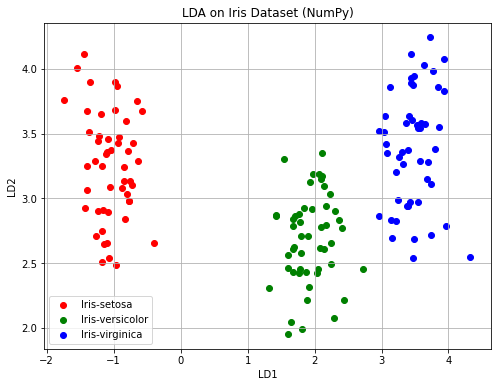

In [13]:
colors = ['red', 'green', 'blue']

plt.figure(figsize=(8,6))

for i, c in enumerate(classes):
    plt.scatter(
        X_lda[y==c,0],
        X_lda[y==c,1],
        color=colors[i],
        label=str(c)
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA on Iris Dataset (NumPy)")
plt.legend()
plt.grid(True)
plt.show()

# Implementation using Scikit-learn

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


        LD1       LD2 Species
0  8.061800 -0.300421  Setosa
1  7.128688  0.786660  Setosa
2  7.489828  0.265384  Setosa
3  6.813201  0.670631  Setosa
4  8.132309 -0.514463  Setosa


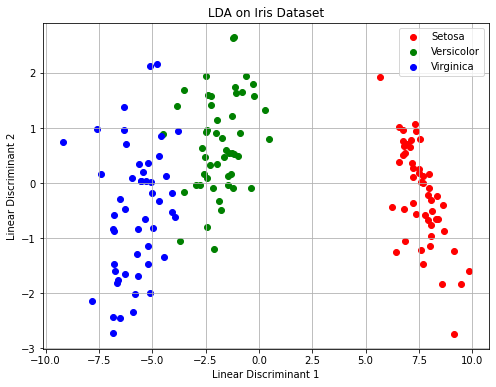


Explained Variance Ratio:
[0.9912126 0.0087874]

Scalings (Linear Discriminants):
[[ 0.68448644 -0.01989153]
 [ 0.66659193 -0.94029176]
 [-3.87282074  1.63962597]
 [-2.13508598 -2.15691008]]


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Load Iris dataset
iris = load_iris()

# Features and target
X = iris.data
y = iris.target

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply LDA
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# Create DataFrame
df = pd.DataFrame(X_lda, columns=["LD1", "LD2"])
df["Species"] = y

# Map target labels to names
species_names = {
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
}

df["Species"] = df["Species"].map(species_names)

# Print transformed data
print(df.head())

# Plot
plt.figure(figsize=(8,6))

colors = {
    "Setosa": "red",
    "Versicolor": "green",
    "Virginica": "blue"
}

for species in species_names.values():
    subset = df[df["Species"] == species]
    plt.scatter(subset["LD1"],
                subset["LD2"],
                label=species,
                color=colors[species])

plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.title("LDA on Iris Dataset")
plt.legend()
plt.grid(True)
plt.show()

# Explained variance ratio
print("\nExplained Variance Ratio:")
print(lda.explained_variance_ratio_)

print("\nScalings (Linear Discriminants):")
print(lda.scalings_)